In [1]:
import numpy as np
import matplotlib.pyplot as plt
from openalea.widgets.plantgl import *
from openalea.plantgl.all import Material, Color3, Scene, Viewer

import sys
from operator import itemgetter
sys.path.append('../data')
from archi_dict import *

from openalea.archicrop.archicrop import ArchiCrop
from openalea.archicrop.display import build_scene, display_scene
from openalea.archicrop.stand import agronomic_plot, compute_domain, regular
from openalea.archicrop.stics_io import get_stics_data
from openalea.archicrop.light_it import illuminate, mean_leaf_irradiance
from openalea.archicrop.viability import compute_viable_params
from openalea.archicrop.simulation import constrain_archi_params, param_sampling
from openalea.archicrop.stics_io import stics_weather_3d

%gui qt

In [2]:
tec_file='../data/usms_STICS/v10/inter_sorghum_cowpea_tec.xml'
sorghum_plant_file='../data/usms_STICS/v10/plant/sorgho_imp_M_v10_plt.xml'
# cowpea_plant_file='../data/usms_STICS/v10/plant/niebe_imp_M_v10_plt.xml'
sorghum_stics_output_file='../data/usms_STICS/v10/mod_s02NT18SorgV2D1.sti'
# cowpea_stics_output_file='../data/usms_STICS/v10/mod_sainter_sorgho_niebe.sti'
weather_file = '../data/ntarla_corr.2018'
location = {  
'longitude': 3.87,
'latitude': 12.58,
'altitude': 800,
'timezone': 'Europe/Paris'}

In [3]:
end = 115

density, daily_dynamics_sorghum, _, _, inter_row = get_stics_data(
        file_tec_xml=tec_file,  # Path to the STICS management XML file
        file_plt_xml=sorghum_plant_file,  # Path to the STICS plant XML file
        stics_output_file=sorghum_stics_output_file,  # Path to the STICS output file
        end=end
    )

# density, daily_dynamics_cowpea, _, _, inter_row = get_stics_data(
#         file_tec_xml=tec_file,  # Path to the STICS management XML file
#         file_plt_xml=cowpea_plant_file,  # Path to the STICS plant XML file
#         stics_output_file=cowpea_stics_output_file,  # Path to the STICS output file
#         end=end
#     )

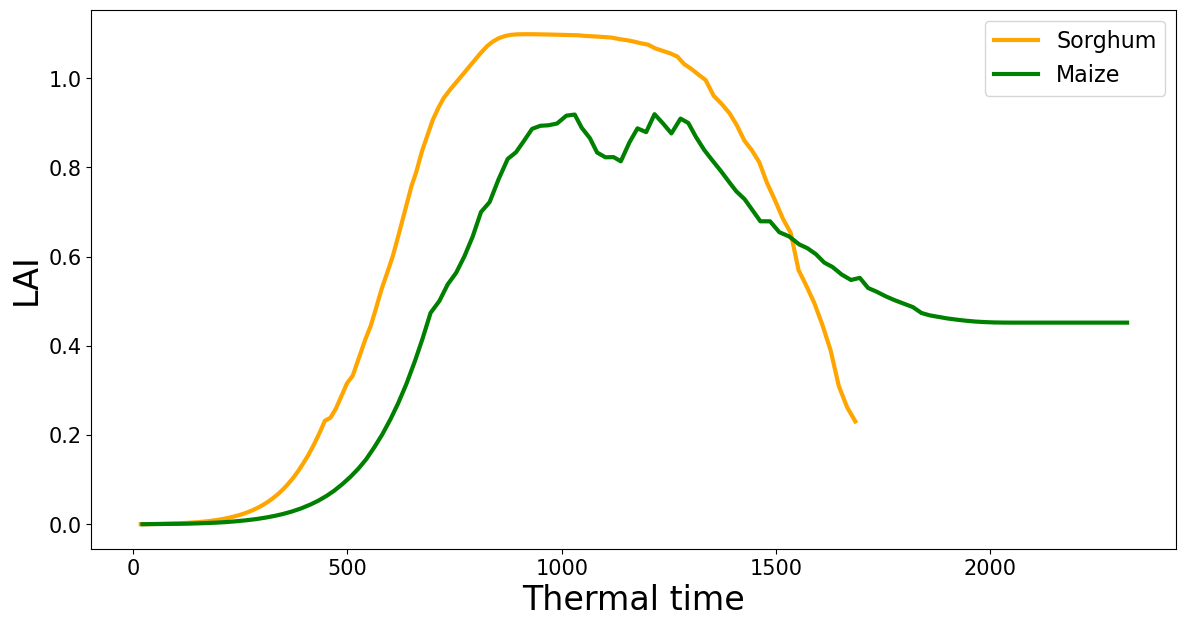

In [64]:
fig = plt.figure(figsize=(14, 7))

labels = ["Sorghum", "Maize"]
colors = ["orange", "green"]
dyn = [daily_dynamics_sorghum, daily_dynamics_cowpea]

for daily_dynamics, color, label in zip(dyn, colors, labels):
    thermal_time = [value["Thermal time"] for value in daily_dynamics.values()]
    leaf_area_plant = [value["Plant leaf area"] for value in daily_dynamics.values()]
    sen_leaf_area_plant = [value["Plant senescent leaf area"] for value in daily_dynamics.values()]
    height_canopy = [value["Plant height"] for value in daily_dynamics.values()]
    dae = range(1,len(thermal_time)+1)
    plt.plot(thermal_time, [(la-sen)*density/10000/2 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color=color, linewidth=3, label=label)
    # plt.plot(dae, [la*density/10000/2 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color=color, linewidth=3, label=label)

plt.xlabel("Thermal time", fontsize=24)
plt.ylabel("LAI", fontsize=24)
plt.legend(fontsize=16)
plt.tick_params(labelsize=15)
plt.show()

In [4]:
def define_params(dynamics_file, plant_file, archi_params, end=-1):    
    # Retrieve STICS management and senescence parameters
    _, daily_dynamics, lifespan, lifespan_early, _ = get_stics_data(
        file_tec_xml=tec_file,  # Path to the STICS management XML file
        file_plt_xml=plant_file,  # Path to the STICS plant XML file
        stics_output_file=dynamics_file,  # Path to the STICS output file
        end=end
    )

    pot_factor_lai = 3
    pot_factor_height = 3

    # Complete ArchiCrop parameters with values from constraint
    archi_params = constrain_archi_params(archi_params=archi_params, daily_dynamics=daily_dynamics, 
                                            lifespan=lifespan, lifespan_early=lifespan_early, 
                                            pot_factor_lai=pot_factor_lai, pot_factor_height=pot_factor_height)
    
    # Generate samples for ArchiCrop parameters 
    param_sets = param_sampling(archi_params=archi_params, n_samples=1)

    # Compute viable parameters wrt the dynamic constraint of LAI and height
    param_sets = compute_viable_params(
        params_sets=param_sets, 
        daily_dynamics=daily_dynamics, 
        pot_factor_lai=pot_factor_lai, pot_factor_height=pot_factor_height, end_veg_indefinite=70)
    
    return param_sets

In [5]:
params_sorghum = define_params(sorghum_stics_output_file, sorghum_plant_file, archi_sorghum, end=end)
sorghum = ArchiCrop(daily_dynamics=daily_dynamics_sorghum, **params_sorghum[1], plant_orientation=0)
sorghum.generate_potential_plant()
growing_sorghum = sorghum.grow_plant()

# params_cowpea = define_params(cowpea_stics_output_file, cowpea_plant_file, archi_cowpea, end=end)
# cowpea = ArchiCrop(daily_dynamics=daily_dynamics_cowpea, **params_cowpea[1], plant_orientation=0)
# cowpea.generate_potential_plant()
# growing_cowpea = cowpea.grow_plant()

{1: [1, 2]}


In [6]:
params_sorghum

{1: {'nb_phy': 18,
  'nb_short_phy': 5,
  'short_phy_height': 3,
  'height': 445.95300000000003,
  'stem_q': 1,
  'diam_base': 4.0,
  'diam_top': 1.5,
  'leaf_area': 10791.0,
  'rmax': np.float64(0.55),
  'skew': np.float64(0.0),
  'wl': 0.12,
  'klig': 0.6,
  'swmax': 0.55,
  'f1': 0.64,
  'f2': 0.92,
  'insertion_angle': 60,
  'scurv': 0.75,
  'curvature': 90,
  'phyllotactic_angle': 180,
  'phyllotactic_deviation': 20,
  'phyllochron': 48.8977688172043,
  'stem_duration': 1.6,
  'leaf_duration': 1.6,
  'nb_tillers': 1,
  'tiller_angle': 20,
  'tiller_delay': 1,
  'reduction_factor': 0.9,
  'gravitropism_coefficient': 0.12,
  'leaf_lifespan': 280.0,
  'leaf_lifespan_early': 224.0}}

In [7]:
green=Color3((0,50,0))
day = 83
list_of_graphs = [growing_sorghum[day]]
# scene, labels = build_scene(growing_sorghum[day], leaf_material=Material(green), stem_material=Material(green), senescence=True)
scene, labels = build_scene(list_of_graphs, leaf_material=Material(green), stem_material=Material(green), senescence=True)
Viewer.display(scene)

In [20]:
params_cowpea

{1: {'nb_phy': 30,
  'nb_short_phy': 2,
  'short_phy_height': 3,
  'height': 149.427,
  'stem_q': 1,
  'diam_base': 1.5,
  'diam_top': 0.5,
  'leaf_area': 13062.200100000002,
  'rmax': np.float64(0.4666666666666667),
  'skew': np.float64(-2.5952548027789093),
  'wl': 0.8,
  'klig': 0.05,
  'swmax': 0.75,
  'f1': 0.5,
  'f2': 0.9,
  'insertion_angle': 80,
  'scurv': 0.5,
  'curvature': 20,
  'phyllotactic_angle': 137.5,
  'phyllotactic_deviation': 45,
  'phyllochron': 43.49173125,
  'stem_duration': 3.0,
  'leaf_duration': 3.0,
  'nb_tillers': 0,
  'tiller_delay': 1,
  'tiller_angle': 30,
  'reduction_factor': 1,
  'gravitropism_coefficient': 0.05,
  'leaf_lifespan': 240.0,
  'leaf_lifespan_early': 192.0}}

In [37]:
# Rows
conv_coef = 100 # Convert from m to cm
inter_row = 0.4
coord_cowpea = (0,0,0)
coord_sorghum = (inter_row * conv_coef, 0,0) 
positions = [coord_cowpea] + [coord_sorghum]
inter_plant = 1.0 / inter_row / density
print(inter_plant)
domain = ((0, -0.5 * inter_plant * conv_coef), (0.5 * inter_row * conv_coef, 0.5 * inter_plant * conv_coef))
lights=[(1,(0,0,-1))]
dates = [value["Date"] for value in daily_dynamics_sorghum.values()]

0.4166666666666667


In [38]:
green = Color3((0,50,0))
day = 75

width = 2
length = 2
nrow = max(1, int(round(float(width) / inter_row))) 
plant_per_row = max(1, int(round(float(length) / inter_plant)))

dx = inter_plant * conv_coef
dy = inter_row * conv_coef
positions_crop, domain = regular(
    nrow * plant_per_row, int(nrow), dx, dy, int(plant_per_row)
)
domain_area = (
    abs(domain[1][0] - domain[0][0]) / conv_coef
    * abs(domain[1][1] - domain[0][1]) / conv_coef
)

# sorting by ranks
positions_crop = sorted(positions_crop, key=itemgetter(1, 0))
print(positions_crop)

list_of_graphs = [growing_sorghum[day]] + [growing_cowpea[day]] 

# scene, labels = build_scene(growing_sorghum[day], leaf_material=Material(green), stem_material=Material(green), senescence=True)
scene, labels = build_scene(list_of_graphs, positions, leaf_material=Material(green), stem_material=Material(green), senescence=True)
Viewer.display(scene)

[(20.833333333333336, 20.0, 0.0), (62.50000000000001, 20.0, 0.0), (104.16666666666669, 20.0, 0.0), (145.83333333333334, 20.0, 0.0), (187.50000000000003, 20.0, 0.0), (20.833333333333336, 60.0, 0.0), (62.50000000000001, 60.0, 0.0), (104.16666666666669, 60.0, 0.0), (145.83333333333334, 60.0, 0.0), (187.50000000000003, 60.0, 0.0), (20.833333333333336, 100.0, 0.0), (62.50000000000001, 100.0, 0.0), (104.16666666666669, 100.0, 0.0), (145.83333333333334, 100.0, 0.0), (187.50000000000003, 100.0, 0.0), (20.833333333333336, 140.0, 0.0), (62.50000000000001, 140.0, 0.0), (104.16666666666669, 140.0, 0.0), (145.83333333333334, 140.0, 0.0), (187.50000000000003, 140.0, 0.0), (20.833333333333336, 180.0, 0.0), (62.50000000000001, 180.0, 0.0), (104.16666666666669, 180.0, 0.0), (145.83333333333334, 180.0, 0.0), (187.50000000000003, 180.0, 0.0)]


In [39]:
green=Color3((0,50,0))
day = 83
list_of_graphs = [growing_sorghum[day]] + [growing_cowpea[day]] 
# scene, labels = build_scene(growing_sorghum[day], leaf_material=Material(green), stem_material=Material(green), senescence=True)
scene, labels = build_scene(list_of_graphs, positions, leaf_material=Material(green), stem_material=Material(green), senescence=True)
Viewer.display(scene)

In [47]:
def simulation_cycle(dates, daily_dynamics, growing_plant1, growing_plant2, positions, domain, lights):

    green=Color3((0,50,0))

    results_cycle = {
            'scene': [],
            'cs': [],
            'raw': [],
            'agg': []
    }

    # Read weather data
    df_weather = stics_weather_3d(filename=weather_file, daily_dynamics=daily_dynamics)

    # Define incident PAR
    incident_rads = list(df_weather.itertuples())
    
    for day in range(1,len(dates)+1):
    # for day in range(80,85):

        list_of_graphs = [growing_plant1[day]] + [growing_plant2[day]] 

        par = incident_rads[day-1].rad * 0.48 * 0.95
    
        scene, labels = build_scene(list_of_graphs, positions, leaf_material=Material(green), stem_material=Material(green), senescence=False)
        cs, raw, agg = illuminate(scene, light=lights, labels=labels, domain=domain, direct=False)
        agg = mean_leaf_irradiance(agg)

        results_cycle['scene'].append(scene)
        results_cycle['cs'].append(cs)
        results_cycle['raw'].append(raw)
        results_cycle['agg'].append(agg)

    return results_cycle


In [48]:
results_cycle = simulation_cycle(dates, daily_dynamics_sorghum, growing_sorghum, growing_cowpea, positions, domain, lights)

In [49]:
sc, v=results_cycle['cs'][80].plot(results_cycle['raw'][80])

In [ ]:
# energy_maize = [results_cycle['agg'][t].loc[0, 'Energy']*density/2 for t in range(5)]
# plt.plot(range(5), energy_maize, color='green')
# energy_sorghum = [results_cycle['agg'][t].loc[1, 'Energy']*density/2 for t in range(5)]
# plt.plot(range(5), energy_sorghum, color='orange')
# plt.plot(range(5), np.array(energy_sorghum) + np.array(energy_maize), color='black')
# plt.show()

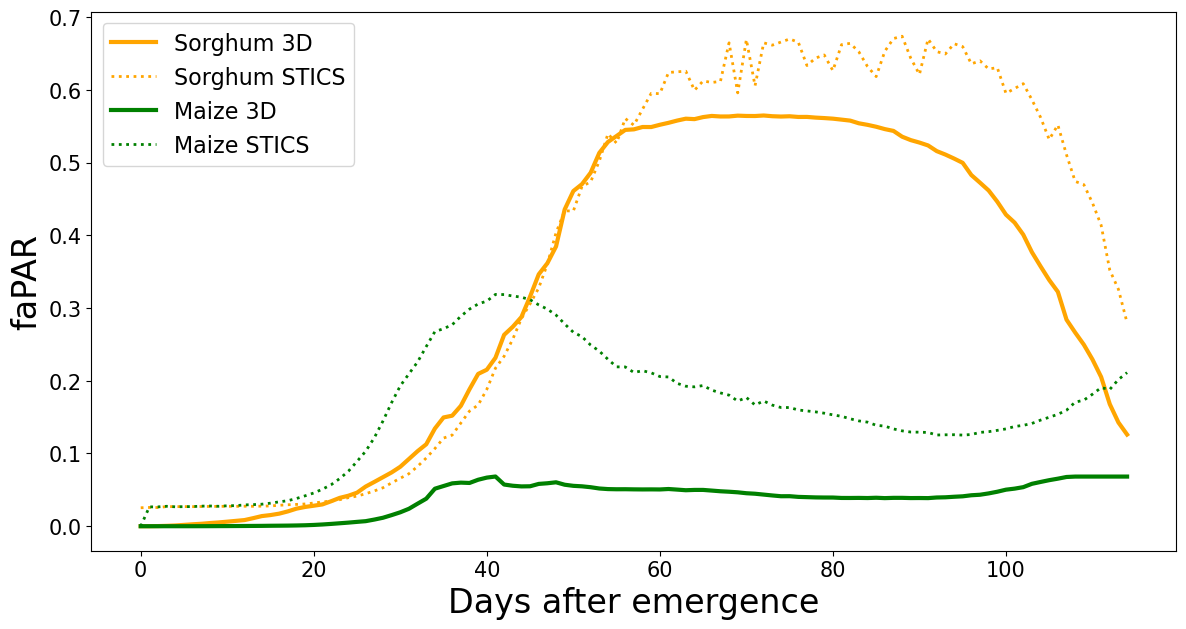

In [69]:
fig = plt.figure(figsize=(14, 7))

for i, (daily_dynamics, color, label) in enumerate(zip(dyn, colors, labels)):
    par_caribu = [results_cycle['agg'][t].loc[i, 'Energy']*density/2 for t in range(len(dates))]
    plt.plot(range(len(dates)), par_caribu, color=color, linewidth=3, label=label+" 3D")
    par_stics = [value["Absorbed PAR"] for value in daily_dynamics.values()]
    plt.plot(range(len(dates)), par_stics, color=color, linewidth=2, linestyle=':', label=label+" STICS")

plt.xlabel("Days after emergence", fontsize=24)
plt.ylabel("faPAR", fontsize=24)
plt.legend(fontsize=16)
plt.tick_params(labelsize=15)
plt.show()

In [51]:
results_cycle['agg'][60:90]

[         Energy      area  Irradiance
 plant                                
 0      0.183981  0.398792    0.461345
 1      0.016850  0.099498    0.169349,
          Energy      area  Irradiance
 plant                                
 0      0.184876  0.406656    0.454626
 1      0.017054  0.103271    0.165138,
          Energy      area  Irradiance
 plant                                
 0      0.185912  0.413492    0.449615
 1      0.016782  0.102914    0.163064,
          Energy      area  Irradiance
 plant                                
 0      0.186772  0.420394    0.444279
 1      0.016495  0.102214    0.161378,
          Energy      area  Irradiance
 plant                                
 0      0.186571  0.424276    0.439741
 1      0.016635  0.104613    0.159010,
          Energy      area  Irradiance
 plant                                
 0      0.187509  0.428543    0.437551
 1      0.016638  0.104406    0.159359,
          Energy      area  Irradiance
 plant             